In [1]:
import h2o

In [2]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK Client VM (Temurin)(build 25.432-b06, mixed mode))
  Starting server from C:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\Cursist\AppData\Local\Temp\tmptlhhadk1
  JVM stdout: C:\Users\Cursist\AppData\Local\Temp\tmptlhhadk1\h2o_Cursist_started_from_python.out
  JVM stderr: C:\Users\Cursist\AppData\Local\Temp\tmptlhhadk1\h2o_Cursist_started_from_python.err


c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\backend\server.py:395: UserWarning:   You have a 32-bit version of Java. H2O works best with 64-bit Java.
  Please download the latest 64-bit Java SE JDK from Oracle.

  warn("  You have a 32-bit version of Java. H2O works best with 64-bit Java.\n"


  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,07 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 days
H2O_cluster_name:,H2O_from_python_Cursist_l2mouv
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,247.5 Mb
H2O_cluster_total_cores:,0
H2O_cluster_allowed_cores:,0
H2O_cluster_status:,"locked, healthy"


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_data = pd.read_csv(url)

# Preprocess the dataset
titanic_data = titanic_data[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']].dropna()
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = titanic_data[['Pclass', 'Sex', 'Age', 'Fare']]
y = titanic_data['Survived']

# Split the dataset into training and testing sets (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply one-hot encoding to 'Sex' and 'Pclass', and standard scaling to 'Age' and 'Fare'
column_transformer = ColumnTransformer(
	transformers=[
		('onehot', OneHotEncoder(drop='first'), ['Pclass', 'Sex']),
		('scaler', StandardScaler(), ['Age', 'Fare'])
	],
	remainder='passthrough'
)

X_train = column_transformer.fit_transform(X_train)
X_test = column_transformer.transform(X_test)

# Train a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate precision and recall
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")

Precision: 0.7209302325581395
Recall: 0.6966292134831461


In [4]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

# Logistic Regression: choose threshold that maximizes F1 on the test set
proba_1 = model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0, 1, 501)

f1s = [f1_score(y_test, (proba_1 >= t).astype(int)) for t in thresholds]
best_t = float(thresholds[int(np.argmax(f1s))])
y_pred_best = (proba_1 >= best_t).astype(int)

print(f"Best threshold (max F1): {best_t:.3f}")
print(f"Precision @ best threshold: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall @ best threshold:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1 @ best threshold:        {f1_score(y_test, y_pred_best):.4f}")

Best threshold (max F1): 0.302
Precision @ best threshold: 0.6698
Recall @ best threshold:    0.7978
F1 @ best threshold:        0.7282


In [5]:
from h2o.automl import H2OAutoML
from sklearn.metrics import precision_score, recall_score

# Convert pandas DataFrames to H2O Frames
h2o_df = h2o.H2OFrame(titanic_data)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
# Convert numpy arrays back to pandas DataFrame
X_train_df = pd.DataFrame(X_train, columns=column_transformer.get_feature_names_out())
X_test_df = pd.DataFrame(X_test, columns=column_transformer.get_feature_names_out())

# Define features and target for H2O (niet echt nodig als in Run H2O AutoML rechtstreeks kolomnamen zetten)
# h2o_df['Survived'] = h2o_df['Survived'].asfactor()  # Convert target to categorical
# h2o_X = list(X_train_df.columns)  # Use transformed column names
# h2o_y = 'Survived'

# Split the H2O Frame into training and testing sets
h2o_train = h2o.H2OFrame(pd.concat([X_train_df, y_train.reset_index(drop=True)], axis=1))
h2o_test = h2o.H2OFrame(pd.concat([X_test_df, y_test.reset_index(drop=True)], axis=1))

# Ensure the target column is treated as categorical
h2o_train['Survived'] = h2o_train['Survived'].asfactor()
h2o_test['Survived'] = h2o_test['Survived'].asfactor()

# Run H2O AutoML
aml = H2OAutoML(max_runtime_secs=300, seed=42)  # Set max runtime to 5 minutes (300 seconds)
aml.train(x=list(X_train_df.columns), y="Survived", training_frame=h2o_train)

# Make predictions
preds = aml.leader.predict(h2o_test)

# Convert predictions to binary (0/1)
preds_bin = preds['predict'].as_data_frame().astype(int)

# Calculate precision and recall
precision_h2o = precision_score(y_test, preds_bin)
recall_h2o = recall_score(y_test, preds_bin)

print(f"Precision (H2O): {precision_h2o}")
print(f"Recall (H2O): {recall_h2o}")

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
12:11:20.538: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Precision (H2O): 0.6979166666666666
Recall (H2O): 0.7528089887640449


c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [7]:
# Display the leaderboard of the top 20 models
lb = aml.leaderboard
print(lb.head(rows=20))

model_id                                                      auc    logloss     aucpr    mean_per_class_error      rmse       mse
StackedEnsemble_AllModels_4_AutoML_1_20260316_121120     0.886048   0.442526  0.858142                0.173445  0.371386  0.137927
StackedEnsemble_AllModels_3_AutoML_1_20260316_121120     0.884863   0.453814  0.865923                0.167134  0.378344  0.143144
StackedEnsemble_BestOfFamily_4_AutoML_1_20260316_121120  0.883719   0.401885  0.867152                0.173328  0.351247  0.123375
GBM_grid_1_AutoML_1_20260316_121120_model_10             0.881966   0.404985  0.869241                0.169797  0.353722  0.125119
DeepLearning_grid_1_AutoML_1_20260316_121120_model_2     0.880697   0.418825  0.861624                0.185474  0.358927  0.128829
StackedEnsemble_BestOfFamily_6_AutoML_1_20260316_121120  0.87952    0.406779  0.864263                0.174889  0.353145  0.124711
StackedEnsemble_AllModels_6_AutoML_1_20260316_121120     0.877341   0.404935  0.862

In [8]:
import pandas as pd
import h2o
from sklearn.metrics import precision_score, recall_score

# Top-5 models from the leaderboard
top5_ids = lb["model_id"].as_data_frame().iloc[:5, 0].tolist()

rows = []
for mid in top5_ids:
    m = h2o.get_model(mid)
    y_pred = m.predict(h2o_test)["predict"].as_data_frame().iloc[:, 0].astype(int)
    rows.append({
        "model_id": mid,
        "algo": getattr(m, "algo", ""),
        "precision(label=1)": precision_score(y_test, y_pred, pos_label=1),
        "recall(label=1)": recall_score(y_test, y_pred, pos_label=1),
    })

pd.DataFrame(rows)

stackedensemble prediction progress: |

c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |

c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |

c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%


c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dat

,model_id,algo,precision(label=1),recall(label=1)
0,StackedEnsemble_AllModels_4_AutoML_1_20260316_...,stackedensemble,0.697917,0.752809
1,StackedEnsemble_AllModels_3_AutoML_1_20260316_...,stackedensemble,0.800000,0.674157
2,StackedEnsemble_BestOfFamily_4_AutoML_1_202603...,stackedensemble,0.759036,0.707865
3,GBM_grid_1_AutoML_1_20260316_121120_model_10,gbm,0.762500,0.685393
4,DeepLearning_grid_1_AutoML_1_20260316_121120_m...,deeplearning,0.711111,0.719101


In [9]:
import numpy as np
import pandas as pd
import h2o
from sklearn.metrics import precision_score, recall_score, f1_score

# Top-5 models from the leaderboard
top5_ids = lb["model_id"].as_data_frame().iloc[:5, 0].tolist()

rows = []
for mid in top5_ids:
    m = h2o.get_model(mid)
    perf = m.model_performance(h2o_test)

    # H2O-provided threshold that maximizes F1 (binomial only)
    thr = perf.find_threshold_by_max_metric("f1")

    preds = m.predict(h2o_test).as_data_frame()
    if "p1" not in preds.columns:
        raise ValueError(f"Model {mid} predictions do not include 'p1' (columns={list(preds.columns)}).")

    y_pred = (preds["p1"].to_numpy(dtype=float) >= float(thr)).astype(int)
    rows.append({
        "model_id": mid,
        "algo": getattr(m, "algo", ""),
        "best_thr(F1)": float(thr),
        "precision@best_thr": precision_score(y_test, y_pred, pos_label=1),
        "recall@best_thr": recall_score(y_test, y_pred, pos_label=1),
        "f1@best_thr": f1_score(y_test, y_pred, pos_label=1),
    })

pd.DataFrame(rows)

stackedensemble prediction progress: |

c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |

c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |

...

███████████████████████████████████████████| (done) 100%
gbm prediction progress: |

c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%


c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,algo,best_thr(F1),precision@best_thr,recall@best_thr,f1@best_thr
0,StackedEnsemble_AllModels_4_AutoML_1_20260316_...,stackedensemble,0.314387,0.691589,0.831461,0.755102
1,StackedEnsemble_AllModels_3_AutoML_1_20260316_...,stackedensemble,0.333244,0.701923,0.820225,0.756477
2,StackedEnsemble_BestOfFamily_4_AutoML_1_202603...,stackedensemble,0.305873,0.720000,0.808989,0.761905
3,GBM_grid_1_AutoML_1_20260316_121120_model_10,gbm,0.289944,0.716981,0.853933,0.779487
4,DeepLearning_grid_1_AutoML_1_20260316_121120_m...,deeplearning,0.205666,0.676190,0.797753,0.731959


In [10]:
# Inspect composition of top5 models at index 3 and 4
import h2o

se_id = top5_ids[3]
gbm_id = top5_ids[4]

se = h2o.get_model(se_id)
gbm = h2o.get_model(gbm_id)

print("StackedEnsemble model_id:", se_id)
print("algo:", getattr(se, "algo", ""))

# Base models (what gets stacked)
base_models = []
try:
    base_models = se.base_models
except Exception:
    try:
        base_models = [bm["name"] for bm in se._model_json["output"].get("base_models", [])]
    except Exception:
        base_models = []
print("# base models:", len(base_models))
print("first base models:", base_models[:10])

# Metalearner (the level-1 model combining base model predictions)
try:
    metalearner = se.metalearner()
    print("metalearner algo:", getattr(metalearner, "algo", ""))
    print("metalearner model_id:", metalearner.model_id)
except Exception as e:
    print("metalearner: <not available>")
    print("reason:", e)

print("\nGBM model_id:", gbm_id)
print("algo:", getattr(gbm, "algo", ""))
try:
    ap = gbm.actual_params
except Exception:
    ap = {}

# Print a few key parameters that describe the shape of the GBM
keys = ["ntrees", "max_depth", "learn_rate", "min_rows", "sample_rate", "col_sample_rate", "nbins", "stopping_rounds", "stopping_metric", "stopping_tolerance"]
for k in keys:
    if k in ap:
        print(f"{k}: {ap[k]}")

StackedEnsemble model_id: GBM_grid_1_AutoML_1_20260316_121120_model_10
algo: gbm
# base models: 0
first base models: []
metalearner: <not available>
reason: type object 'ModelBase' has no attribute 'metalearner'

GBM model_id: DeepLearning_grid_1_AutoML_1_20260316_121120_model_2
algo: deeplearning
stopping_rounds: 0
stopping_metric: logloss
stopping_tolerance: 0.04476614810358452


For the “top‑5 @ best‑F1 threshold” table (Cell 9), the entries at **index 3** and **index 4** correspond to:

## 1) Index 3 — StackedEnsemble (BestOfFamily)

This model is a **stacked ensemble** (a “model of models”):

- **Base models (5 total)**:  
  It stacks predictions from these 5 different learners:
  - `DeepLearning_grid_..._model_2` (neural net)
  - `GBM_grid_..._model_10` (gradient boosted trees)
  - `DRF_1_...` (random forest)
  - `GLM_1_...` (logistic regression / GLM)
  - `XRT_1_...` (extra-randomized trees)

- **Metalearner (the combiner)**:  
  The “level‑1” model that combines those base predictions is a **GLM** (`metalearner algo: glm`).  
  Intuitively: the metalearner learns weights like  
  “trust GBM a bit here, DRF a bit there, etc.” using base model predictions as inputs.

- **Why it’s called `BestOfFamily`**:  
  AutoML picks the *best* model it found in each algorithm family (GBM, DRF, XRT, GLM, DeepLearning here) and then stacks them.

So “how it looks” is: **5 separate models → their predicted probabilities become features → a GLM learns how to combine them → final probability/prediction**.

## 2) Index 4 — GBM (Gradient Boosting Machine)

This model is a **single GBM**, not an ensemble of different algorithm types:

- It builds an **additive sequence of decision trees** where each new tree corrects errors of the previous ones.
- In your run, key settings that describe its shape:
  - `ntrees: 40` → 40 trees in the boosted sequence
  - `max_depth: 13` → trees can be fairly deep/complex
  - `learn_rate: 0.1` → shrinkage; each tree contributes 10% step size
  - `sample_rate: 0.6` → each tree trains on 60% of rows (stochastic boosting)
  - `col_sample_rate: 0.4` → each tree uses 40% of columns (adds diversity)
  - `min_rows: 15` → minimum rows in a leaf (regularization)
  - `nbins: 20` → binning resolution for numeric splits

So “how it looks” is: **40 decision trees added one-by-one**, producing a final probability via the boosted sum (with regularization via learning rate + subsampling).

If you want, I can add 1 more small cell that prints the **metalearner coefficients** (the actual weights) so you can see *which base models the ensemble relies on most*.

Made changes.

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
GBM_grid_1_AutoML_1_20260316_121120_model_3,0.865169,0.44537,0.857756,0.183119,0.373602,0.139578,134,0.050886,GBM
GBM_3_AutoML_1_20260316_121120,0.862137,0.450859,0.847873,0.195024,0.378465,0.143236,116,0.036781,GBM
GBM_grid_1_AutoML_1_20260316_121120_model_10,0.861334,0.451103,0.845977,0.192081,0.379576,0.144078,106,0.039607,GBM
GBM_4_AutoML_1_20260316_121120,0.860531,0.454531,0.84023,0.193731,0.381444,0.1455,121,0.038937,GBM
GBM_grid_1_AutoML_1_20260316_121120_model_4,0.860309,0.449493,0.838758,0.177501,0.375639,0.141105,113,0.04291,GBM
GBM_2_AutoML_1_20260316_121120,0.858837,0.448262,0.851727,0.191056,0.377492,0.1425,123,0.042116,GBM
StackedEnsemble_BestOfFamily_2_AutoML_1_20260316_121120,0.858391,0.456447,0.842687,0.207954,0.381681,0.14568,247,0.067501,StackedEnsemble
StackedEnsemble_AllModels_1_AutoML_1_20260316_121120,0.858035,0.453587,0.843388,0.197699,0.380602,0.144858,252,0.065646,StackedEnsemble
GBM_grid_1_AutoML_1_20260316_121120_model_9,0.856965,0.454104,0.846907,0.191056,0.379211,0.143801,139,0.053998,GBM
StackedEnsemble_BestOfFamily_3_AutoML_1_20260316_121120,0.856251,0.464093,0.840899,0.201668,0.385269,0.148432,244,0.06259,StackedEnsemble


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## StackedEnsemble_AllModels_4_AutoML_1_20260316_121120

,0,1,Error,Rate
0,93.0,33.0,0.2619,(33.0/126.0)
1,15.0,74.0,0.1685,(15.0/89.0)
Total,108.0,107.0,0.2233,(48.0/215.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

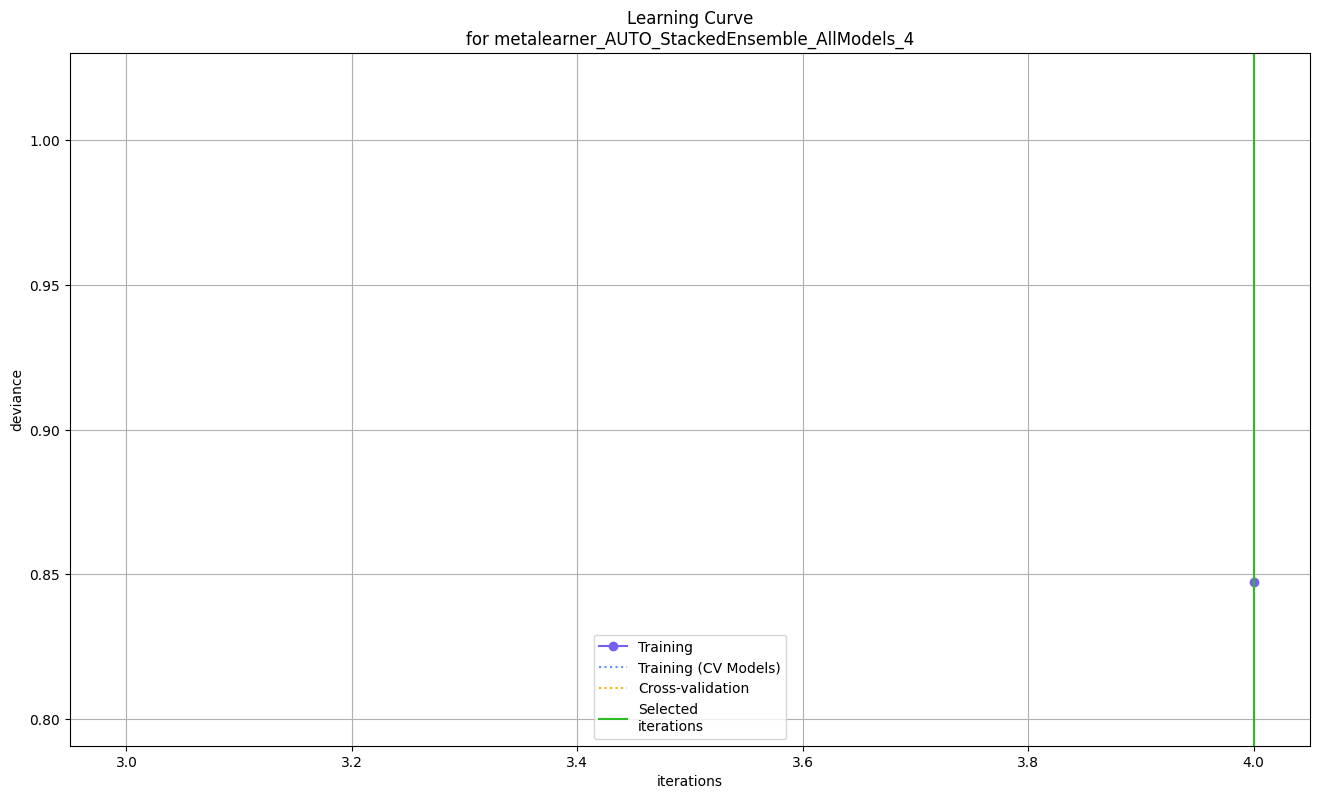

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

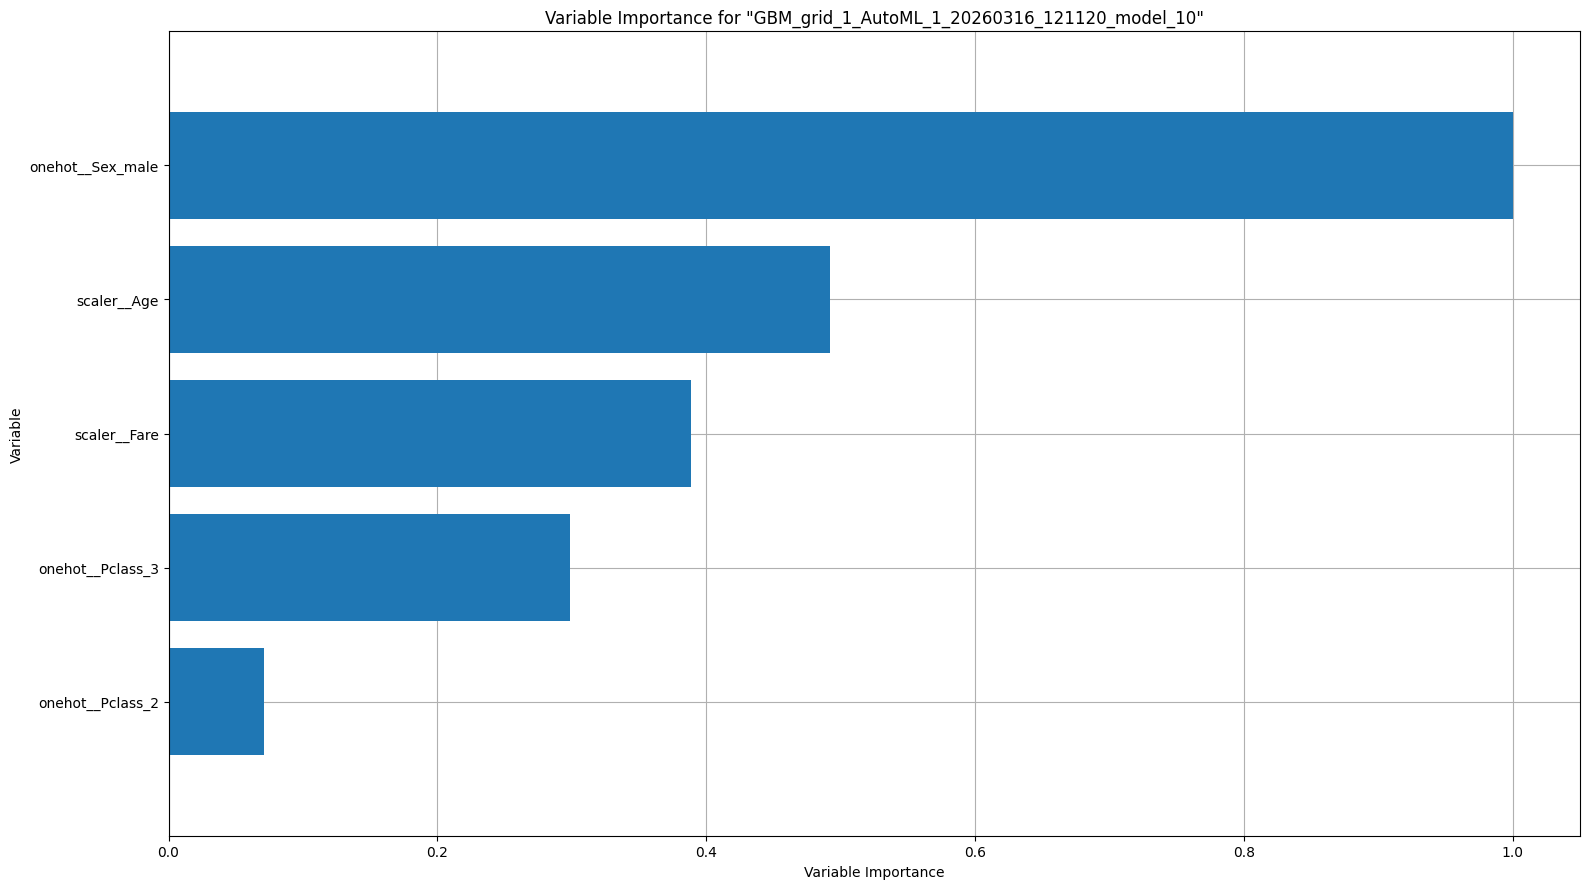

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

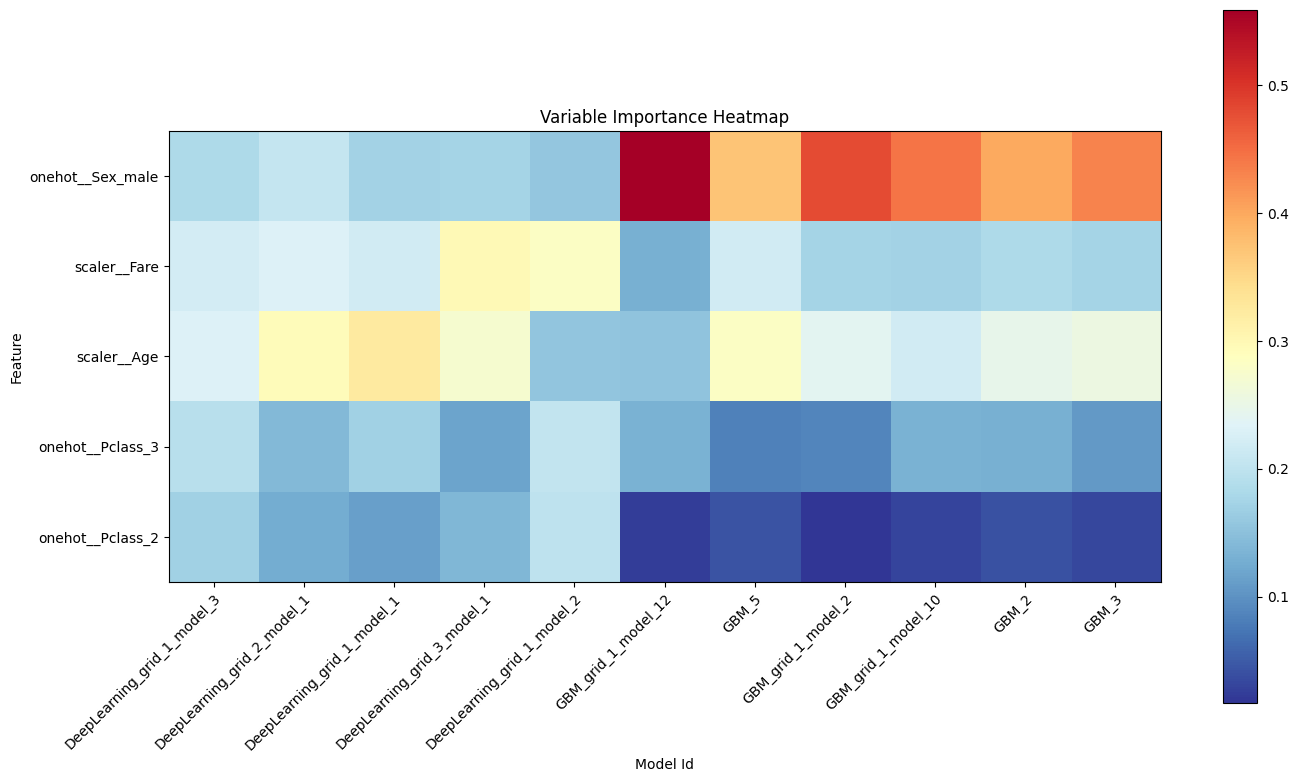

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

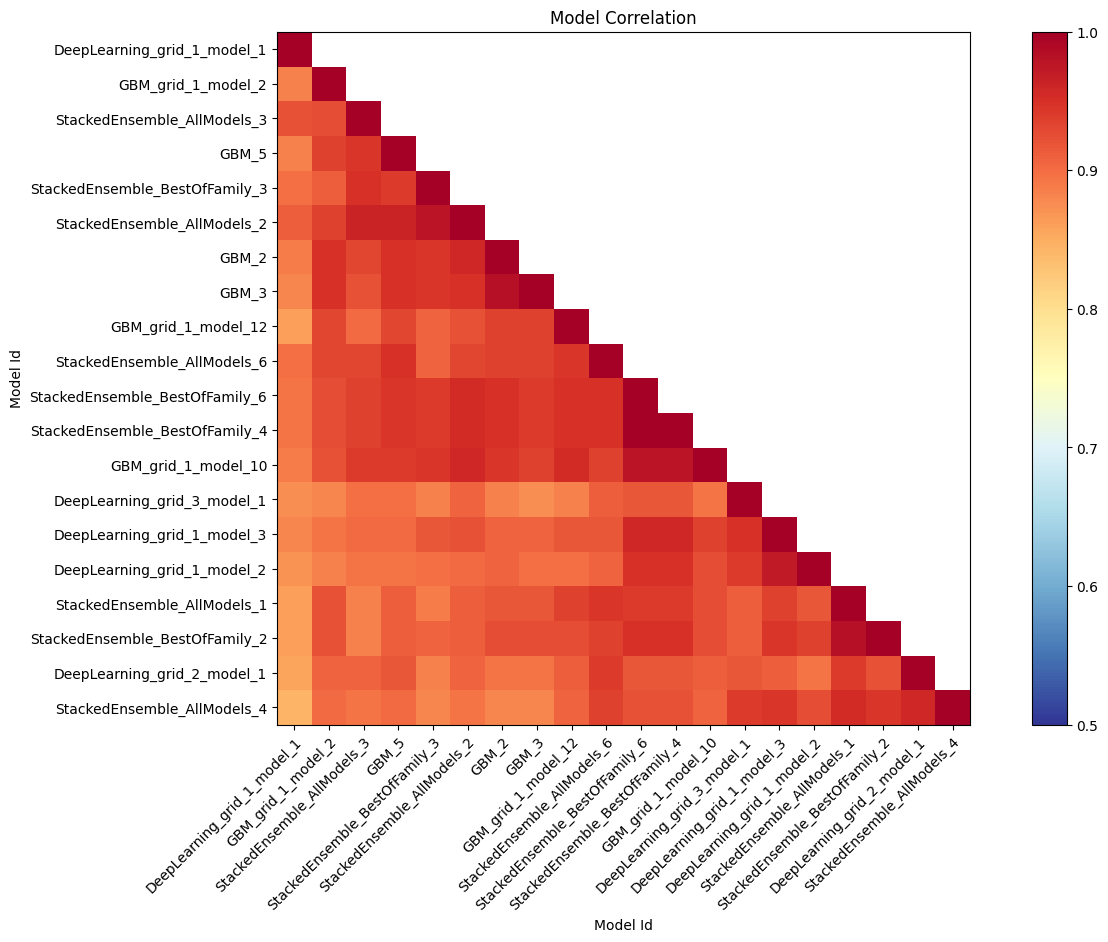

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

H2OResponseError: Server error java.lang.IllegalArgumentException:
  Error: Incorrect number of arguments; 'cols_py' expects 2 but was passed 3
  Request: POST /99/Rapids
    data: {'ast': "(tmp= py_924_sid_9540 (levels (tmp= py_923_sid_9540 (as.factor (cols_py py_922_sid_9540 np.str_('Survived'))))))", 'session_id': '_sid_9540'}


In [12]:
# Explain the leader model on the test dataset
exa = aml.explain(h2o_test)